In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
import joblib
import time
!pip install lime
import shap
import lime
import lime.lime_tabular


from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,

)
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


In [ ]:
df = pd.read_csv('CredGuardV2 (1).csv')
df.head()

,timestamp,src_ip,username,password,asn,location,status,label,source,ip_type,...,fail_attempt,fail_ratio,mean_iat,std_iat,password_length,password_complexity,day_of_week,hour,hour_sin,hour_cos
0,2024-08-15 02:12:37,1.180.230.98,nobody,666666,4134,CN,0,1,df1,1,...,1,1.0,0.0,0.0,6.0,1.0,3,2,5.000000e-01,0.866025
1,2024-08-14 16:28:57,1.212.24.36,support,p@ssw0rd,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,8.0,3.0,2,16,-8.660254e-01,-0.500000
2,2024-08-15 12:26:59,1.213.180.227,guest,44444444,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,8.0,1.0,3,12,1.224647e-16,-1.000000
3,2024-08-15 04:11:52,1.214.209.210,login,0,3786,KR,0,1,df1,1,...,1,1.0,0.0,0.0,1.0,1.0,3,4,8.660254e-01,0.500000
4,2024-08-14 22:40:26,1.235.192.130,a123456789,a123456789,9318,KR,0,1,df1,1,...,1,1.0,0.0,0.0,10.0,2.0,2,22,-5.000000e-01,0.866025


In [ ]:
df.shape

(1019867, 22)

In [ ]:
df.dtypes

,0
timestamp,object
src_ip,object
username,object
password,object
asn,object
location,object
status,int64
label,int64
source,object
ip_type,int64


Value counts in label column:
label
0    510183
1    509684
Name: count, dtype: int64


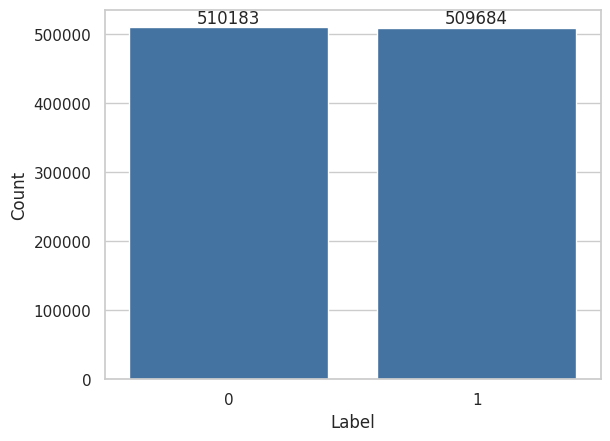

In [ ]:
sns.set_theme(style="whitegrid")

ax = sns.countplot(x='label', data=df, color='#3572B0')
ax.bar_label(ax.containers[0])
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
print("Value counts in label column:")
print(df['label'].value_counts())

plt.show()

Feature Engineering

In [ ]:
X = df.copy()
feature_groups = {}

# TIMESTAMP FEATURES
X['timestamp'] = pd.to_datetime(X['timestamp'], format='mixed', errors='coerce')
X['is_time_missing'] = X['timestamp'].isna().astype('int8')
X['hr']  = X['timestamp'].dt.hour.fillna(0).astype('int8')
X['dow'] = X['timestamp'].dt.dayofweek.fillna(0).astype('int8')
X['is_wknd?']  = (X['dow'].isin([4, 5])).astype('int8')
X['is_night?'] = ((X['hr'] < 6) | (X['hr'] >= 23)).astype('int8')
X = X.drop(columns=['timestamp'])

feature_groups['time'] = ['hr', 'dow', 'is_wknd?', 'is_night?']

# USERNAME FEATURES
X['username'] = X['username'].astype(str)

# PASSWORD FEATURES
X['p_len'] = pd.to_numeric(X['password_length'], errors='coerce').fillna(0).astype('int8')
X['p_comp'] = pd.to_numeric(X['password_complexity'], errors='coerce').fillna(0).astype('int8')

X['has_num'] = X['password'].astype(str).apply(lambda x: 1 if any(c.isdigit() for c in str(x)) else 0).astype('int8')
X['has_spec'] = X['password'].astype(str).apply(
    lambda x: 1 if any((not c.isalnum()) and (not c.isspace()) for c in x) else 0
).astype('int8')

X['p_score'] = ((X['p_comp'] * X['p_len']) / 10).astype('float32')

feature_groups['password'] = ['p_len', 'p_comp', 'has_num', 'has_spec', 'p_score']

# IAT FEATURES
X['mean_iat'] = pd.to_numeric(X['mean_iat'], errors='coerce').fillna(0).astype('float32')
X['std_iat'] = pd.to_numeric(X['std_iat'], errors='coerce').fillna(0).astype('float32')
X['iat_var'] = (X['std_iat'] / (X['mean_iat'].clip(lower=1))).astype('float32')

feature_groups['iat'] = ['mean_iat', 'std_iat', 'iat_var']


# LOGIN FEATURES
X['tries'] = pd.to_numeric(X['login_attempt'], errors='coerce').fillna(0).astype('int16')
X['fails'] = pd.to_numeric(X['fail_attempt'], errors='coerce').fillna(0).astype('int16')
X['fail_rate'] = pd.to_numeric(X['fail_ratio'], errors='coerce').fillna(0).astype('float32')

feature_groups['login'] = ['tries', 'fails', 'fail_rate']

X['target'] = X['label'].astype('int8')
print("Target distribution (0: Normal, 1: Attack):")
print(X['target'].value_counts())

Target distribution (0: Normal, 1: Attack):
target
0    510183
1    509684
Name: count, dtype: int64


Train\Test split

In [ ]:
bad_features = ['label', 'target', 'status']
X_final = X.drop(columns=bad_features, errors='ignore')
y_final = X['target']

# 70% for Training
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(
    gss1.split(X_final, y_final, groups=X_final['src_ip']))

X_train = X_final.iloc[train_idx].copy()
y_train = y_final.iloc[train_idx].copy()
X_temp = X_final.iloc[temp_idx].copy()
y_temp = y_final.iloc[temp_idx].copy()

# 30% (15% for Test)(15% for Validation)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(
    gss2.split(X_temp, y_temp, groups=X_temp['src_ip']))

X_val = X_temp.iloc[val_idx].copy()
y_val = y_temp.iloc[val_idx].copy()
X_test = X_temp.iloc[test_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

print(f"Train: {len(X_train)} ({len(X_train)/len(X_final)*100:.2f}%)")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X_final)*100:.2f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X_final)*100:.2f}%)")

print("\n" + "="*50 + "\n")

def print_distribution(y, name):
    dist = y.value_counts(normalize=True) * 100
    print(f"{name} distribution:")
    print(dist)
    print("-" * 40)

print_distribution(y_train, "Train")
print_distribution(y_val, "Validation")
print_distribution(y_test, "Test")

train_ips = set(X_train['src_ip'])
val_ips   = set(X_val['src_ip'])
test_ips  = set(X_test['src_ip'])

print(f"\nOverlap Train-Val: {len(train_ips & val_ips)}")
print(f"Overlap Train-Test: {len(train_ips & test_ips)}")
print(f"Overlap Val-Test: {len(val_ips & test_ips)}")

X_train = X_train.drop(columns=['src_ip'])
X_val   = X_val.drop(columns=['src_ip'])
X_test  = X_test.drop(columns=['src_ip'])

print("\n src_ip removed")

Train: 704222 (69.05%)
Validation: 173022 (16.97%)
Test: 142623 (13.98%)


Train distribution:
target
0    52.530026
1    47.469974
Name: proportion, dtype: float64
----------------------------------------
Validation distribution:
target
1    59.585486
0    40.414514
Name: proportion, dtype: float64
----------------------------------------
Test distribution:
target
1    50.688879
0    49.311121
Name: proportion, dtype: float64
----------------------------------------

Overlap Train-Val: 0
Overlap Train-Test: 0
Overlap Val-Test: 0

 src_ip removed


In [ ]:
u_map = X_train['username'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['u_freq'] = ds['username'].map(u_map).fillna(0).astype('float32')
feature_groups['user'] = ['u_freq']


loc_map = X_train['location'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['loc_freq'] = ds['location'].map(loc_map).fillna(0).astype('float32')

asn_map = X_train['asn'].value_counts(normalize=True)
for ds in [X_train, X_val, X_test]:
    ds['asn_freq'] = ds['asn'].map(asn_map).fillna(0).astype('float32')
feature_groups['network'] = ['asn_freq', 'loc_freq']

failure_threshold = X['fail_rate'].quantile(0.95)
fast_limit = X['mean_iat'].quantile(0.05)
reg_limit  = X['std_iat'].quantile(0.10)

for ds in [X_train, X_val, X_test]:
    ds['is_v_fast?'] = (ds['mean_iat'] < fast_limit).astype('int8')
    ds['is_v_reg?']  = (ds['std_iat'] < reg_limit).astype('int8')
    ds['fail_rate']  = pd.to_numeric(ds['fail_ratio'], errors='coerce').fillna(0).astype('float32')
    ds['is_failure?'] = (ds['fail_rate'] >= failure_threshold).astype('int8')

    ds['risk_score'] = (
        ds['is_failure?'] * 3 +
        ds['is_v_fast?'] * 2 +
        (ds['p_score'] < 3).astype(int) * 2 +
        ds['is_night?'] * 1 +
        ds['is_wknd?'] * 1
    ).astype('int8')

feature_groups['iat'] = ['is_v_fast?', 'is_v_reg?']
feature_groups['login'] = ['fail_rate', 'is_failure?']
feature_groups['risk'] = ['risk_score']

Select Features + Target

In [ ]:
# PREPARE TRAINING FEATURES
training_features = [
    'hr', 'dow', 'is_wknd?', 'is_night?',
    'p_len', 'p_comp', 'has_num', 'has_spec', 'p_score',
    'u_freq', 'loc_freq', 'asn_freq',
    'mean_iat', 'std_iat', 'iat_var','is_v_fast?', 'is_v_reg?',
    'tries', 'fails', 'fail_rate', 'is_failure?'
]

X_train_final = X_train[training_features].copy()
X_val_final   = X_val[training_features].copy()
X_test_final  = X_test[training_features].copy()

y_train_final = y_train.copy()
y_val_final   = y_val.copy()
y_test_final  = y_test.copy()

print("Select Features:")
print(f"Total features: {len(training_features)}")
print(f"Groups: {list(feature_groups.keys())}")
print(f"Feature matrix: {X_final.shape}")
print(f"Target vector: {y_final.shape}")
print(f"Target distribution:\n{y_final.value_counts().sort_index()}")

Select Features:
Total features: 21
Groups: ['time', 'password', 'iat', 'login', 'user', 'network', 'risk']
Feature matrix: (1019867, 33)
Target vector: (1019867,)
Target distribution:
target
0    510183
1    509684
Name: count, dtype: int64


Scale Feature

In [ ]:
X_train_num = X_train.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')
X_val_num   = X_val.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')
X_test_num  = X_test.select_dtypes(include=['number']).drop(columns=['src_ip'], errors='ignore')

scaler = StandardScaler()
cols = X_train_num.columns

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_final), columns=training_features)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val_final), columns=training_features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_final), columns=training_features)

Reshape Data For CNN

In [ ]:
X_train_cnn = X_train_scaled.values.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_val_cnn = X_val_scaled.values.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.values.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_val_cnn shape: {X_val_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

X_train_cnn shape: (704222, 21, 1)
X_val_cnn shape: (173022, 21, 1)
X_test_cnn shape: (142623, 21, 1)


Class Weight

In [ ]:
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print("CLASS WEIGHTS:")
print(f"  Normal (0): {class_weight_dict[0]:.3f}")
print(f"  Attack (1): {class_weight_dict[1]:.3f}")

CLASS WEIGHTS:
  Normal (0): 0.952
  Attack (1): 1.053


Build CNN Model

In [ ]:
def create_cnn_model_binary(input_shape):
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),

        # Conv1D Block 1
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.2),

        # Conv1D Block 2
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Dropout(0.3),

        # Conv1D Block 3
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.3),

        # Dense layers
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        # Output layer - BINARY CLASSIFICATION
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# Create model
cnn_model = create_cnn_model_binary((X_train_cnn.shape[1], 1))

In [ ]:
# Model summary
print("\n CNN Architecture:")
cnn_model.summary()

# Compile model
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
callbacks = [early_stop, reduce_lr, checkpoint]


 CNN Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 21, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 21, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 10, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 5, 64)          │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,585 (232.75 KB)

 Trainable params: 58,817 (229.75 KB)

 Non-trainable params: 768 (3.00 KB)

 Train CNN Model

In [ ]:
history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7601 - loss: 0.4607
Epoch 1: val_accuracy improved from None to 0.81791, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 128s 90ms/step - accuracy: 0.7812 - loss: 0.4166 - val_accuracy: 0.8179 - val_loss: 0.3322 - learning_rate: 0.0010
Epoch 2/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7953 - loss: 0.3843
Epoch 2: val_accuracy improved from 0.81791 to 0.82138, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 121s 88ms/step - accuracy: 0.7966 - loss: 0.3813 - val_accuracy: 0.8214 - val_loss: 0.3280 - learning_rate: 0.0010
Epoch 3/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7996 - loss: 0.3754
Epoch 3: val_accuracy improved from 0.82138 to 0.82628, saving model to best_cnn_model.h5



Epoch 3: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 141s 88ms/step - accuracy: 0.8005 - loss: 0.3733 - val_accuracy: 0.8263 - val_loss: 0.3183 - learning_rate: 0.0010
Epoch 4/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8025 - loss: 0.3692
Epoch 4: val_accuracy improved from 0.82628 to 0.83175, saving model to best_cnn_model.h5



Epoch 4: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 119s 87ms/step - accuracy: 0.8036 - loss: 0.3678 - val_accuracy: 0.8317 - val_loss: 0.3185 - learning_rate: 0.0010
Epoch 5/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8050 - loss: 0.3657
Epoch 5: val_accuracy did not improve from 0.83175
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 119s 86ms/step - accuracy: 0.8059 - loss: 0.3644 - val_accuracy: 0.8315 - val_loss: 0.3298 - learning_rate: 0.0010
Epoch 6/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8069 - loss: 0.3625
Epoch 6: val_accuracy improved from 0.83175 to 0.83358, saving model to best_cnn_model.h5



Epoch 6: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 120s 87ms/step - accuracy: 0.8076 - loss: 0.3613 - val_accuracy: 0.8336 - val_loss: 0.3249 - learning_rate: 0.0010
Epoch 7/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.8088 - loss: 0.3593
Epoch 7: val_accuracy improved from 0.83358 to 0.83393, saving model to best_cnn_model.h5



Epoch 7: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 120s 88ms/step - accuracy: 0.8093 - loss: 0.3586 - val_accuracy: 0.8339 - val_loss: 0.3231 - learning_rate: 0.0010
Epoch 8/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8099 - loss: 0.3576
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 8: val_accuracy improved from 0.83393 to 0.83628, saving model to best_cnn_model.h5



Epoch 8: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 123s 90ms/step - accuracy: 0.8103 - loss: 0.3570 - val_accuracy: 0.8363 - val_loss: 0.3220 - learning_rate: 0.0010
Epoch 9/50
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8122 - loss: 0.3548
Epoch 9: val_accuracy improved from 0.83628 to 0.83806, saving model to best_cnn_model.h5



Epoch 9: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 119s 86ms/step - accuracy: 0.8128 - loss: 0.3536 - val_accuracy: 0.8381 - val_loss: 0.3312 - learning_rate: 5.0000e-04
Epoch 10/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8134 - loss: 0.3524
Epoch 10: val_accuracy did not improve from 0.83806
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 142s 86ms/step - accuracy: 0.8137 - loss: 0.3520 - val_accuracy: 0.8351 - val_loss: 0.3318 - learning_rate: 5.0000e-04
Epoch 11/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8151 - loss: 0.3514
Epoch 11: val_accuracy did not improve from 0.83806
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 118s 86ms/step - accuracy: 0.8150 - loss: 0.3508 - val_accuracy: 0.8366 - val_loss: 0.3316 - learning_rate: 5.0000e-04
Epoch 12/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8153 - loss: 0.3507
Epoch 12: val_accuracy improved from 0.83806 to 0.83873, saving model to best_cnn_model.h5



Epoch 12: finished saving model to best_cnn_model.h5
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 122s 89ms/step - accuracy: 0.8157 - loss: 0.3499 - val_accuracy: 0.8387 - val_loss: 0.3324 - learning_rate: 5.0000e-04
Epoch 13/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8168 - loss: 0.3494
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 13: val_accuracy did not improve from 0.83873
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 140s 87ms/step - accuracy: 0.8170 - loss: 0.3488 - val_accuracy: 0.8354 - val_loss: 0.3296 - learning_rate: 5.0000e-04
Epoch 14/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8175 - loss: 0.3481
Epoch 14: val_accuracy did not improve from 0.83873
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 146s 90ms/step - accuracy: 0.8179 - loss: 0.3470 - val_accuracy: 0.8367 - val_loss: 0.3383 - learning_rate: 2.5000e-04
Epoch 15/50
1375/1376 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.8179 - loss: 0.3467
Epoch 15: val_accuracy did not improve from 

Model Evaluation

In [ ]:
y_train_pred_probs = cnn_model.predict(X_train_scaled)
y_val_pred_probs   = cnn_model.predict(X_val_scaled)
y_test_pred_probs  = cnn_model.predict(X_test_scaled)

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_train_pred = (y_train_pred_probs > 0.5).astype(int)
y_val_pred   = (y_val_pred_probs > 0.5).astype(int)
y_test_pred  = (y_test_pred_probs > 0.5).astype(int)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc   = accuracy_score(y_val, y_val_pred)
test_acc  = accuracy_score(y_test, y_test_pred)
test_f1   = f1_score(y_test, y_test_pred, average='weighted')

print("Accuracy Scores:")
print(f"  • Training: {train_acc:.4f}")
print(f"  • Test: {test_acc:.4f}")
print(f"  • Validation: {val_acc:.4f}")
print(f"  • F1-Score (Weighted): {test_f1:.4f}")

print("Unique in y_test:", np.unique(y_test))
print("Unique in y_test_pred:", np.unique(y_test_pred))

22007/22007 ━━━━━━━━━━━━━━━━━━━━ 72s 3ms/step
5407/5407 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step
4457/4457 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
Accuracy Scores:
  • Training: 0.8082
  • Test: 0.8050
  • Validation: 0.8263
  • F1-Score (Weighted): 0.8041
Unique in y_test: [0 1]
Unique in y_test_pred: [0 1]


 Accuracy comparison bar chart

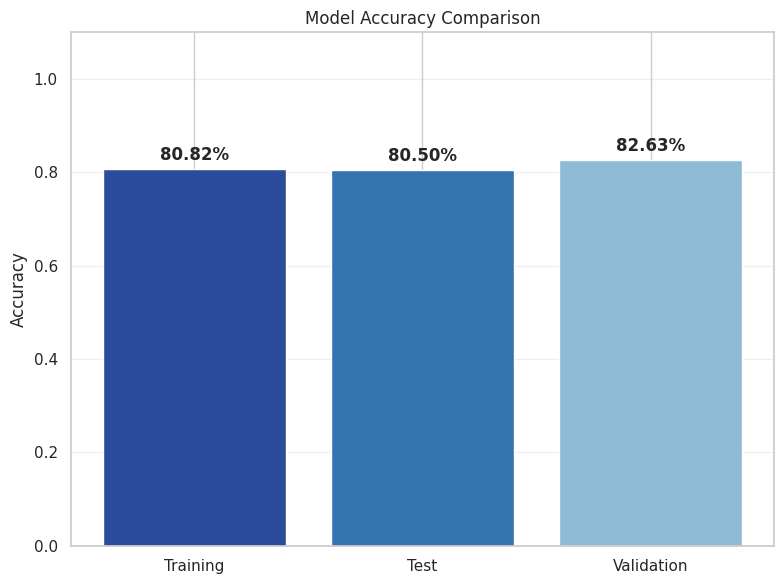

In [ ]:
plt.figure(figsize=(8, 6))
accuracies = [train_acc, test_acc, val_acc]
bars = plt.bar(['Training', 'Test', 'Validation'], accuracies,
               color=['#2B4C9B', '#3572B0', '#8DBBD5'])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, 1.1)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy Comparison')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Class Distribution Bar chart

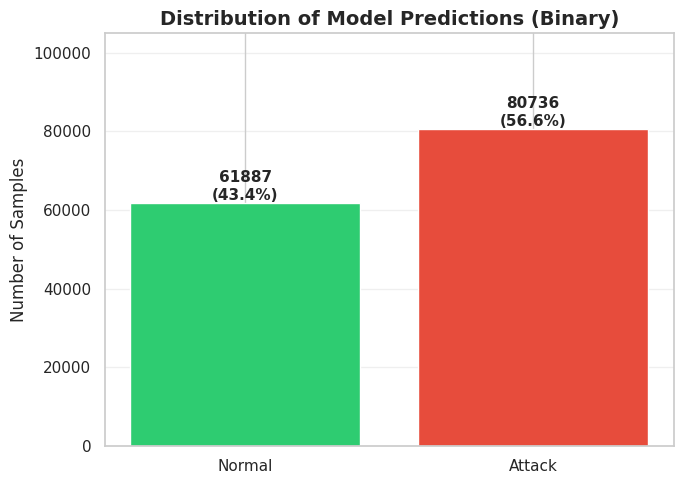

In [ ]:
plt.figure(figsize=(7, 5))
colors = ['#2ECC71', '#E74C3C']

class_names = ['Normal', 'Attack']

class_counts = pd.Series(y_test_pred.flatten()).value_counts().sort_index()
total = len(y_test_pred)

bars = plt.bar(class_names, [class_counts.get(i, 0) for i in range(2)], color=colors)

plt.ylim(0, class_counts.max() * 1.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribution of Model Predictions (Binary)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

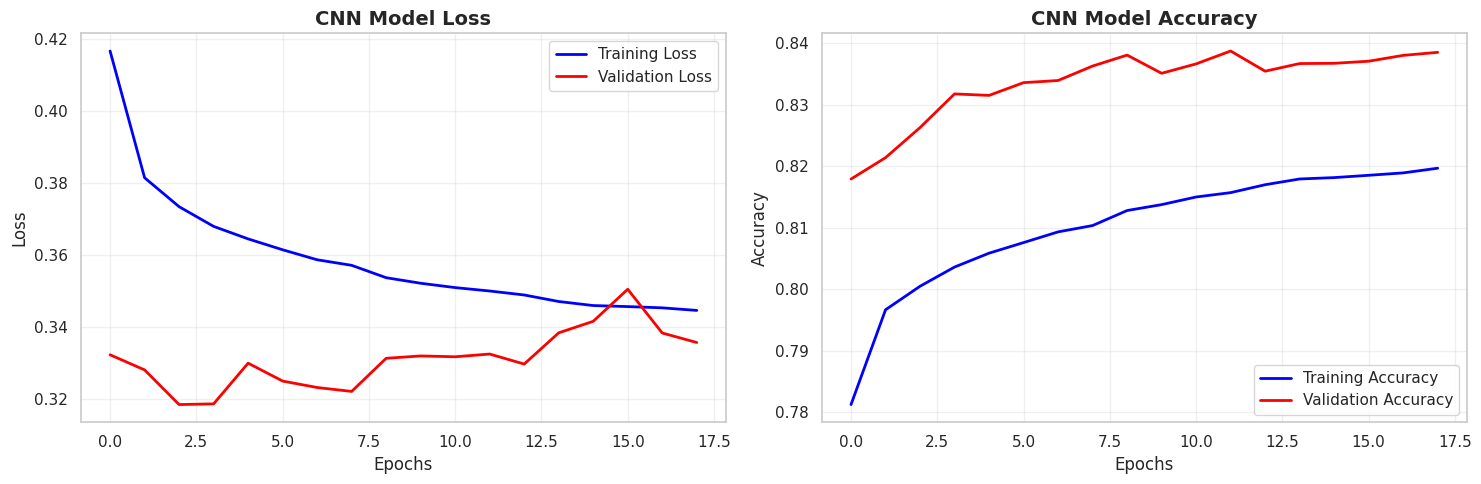

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0].set_title('CNN Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
axes[1].set_title('CNN Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Mutual Information

Top 15 Mutual Information Scores:
                Feature  MI_Score
5              mean_iat  0.177270
6               std_iat  0.161383
23              iat_var  0.155123
4            fail_ratio  0.133250
26            fail_rate  0.132708
19               p_comp  0.106486
8   password_complexity  0.104324
7       password_length  0.099769
22              p_score  0.097877
18                p_len  0.096540
3          fail_attempt  0.095982
25                fails  0.093902
1                   iat  0.074320
2         login_attempt  0.057623
24                tries  0.055469


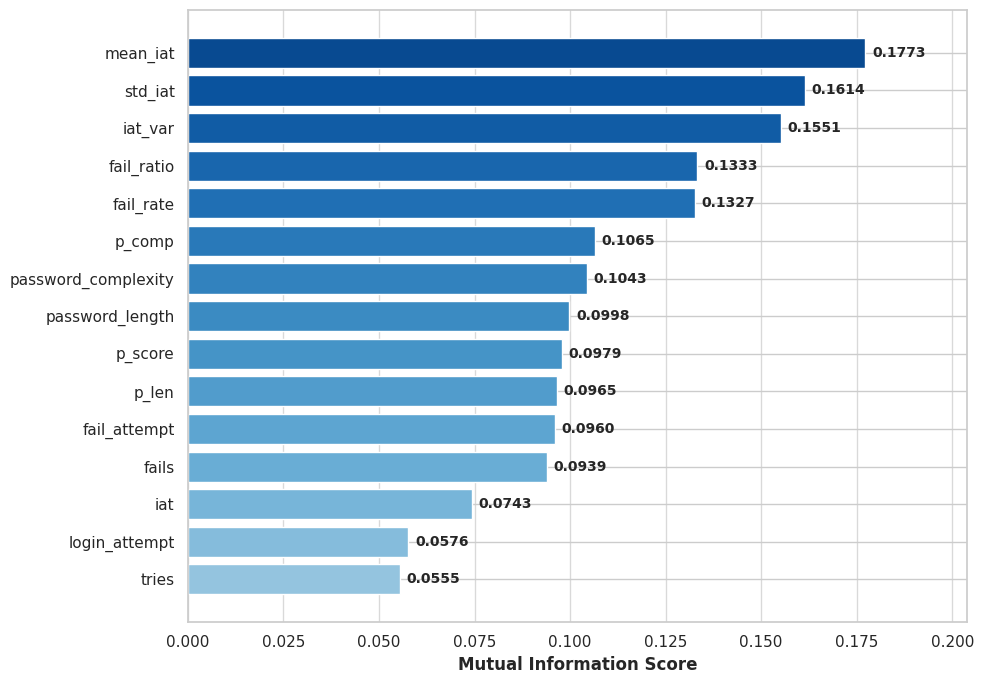

In [ ]:
feature_columns = X_final.select_dtypes(include=['number']).columns

X_train_df = pd.DataFrame(X_train, columns=feature_columns)

X_train_df = X_train_df.fillna(0)

sample_idx = np.random.choice(len(X_train_df), size=20000, replace=False)
X_sample = X_train_df.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)

mi_df = pd.DataFrame({
    'Feature': feature_columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print("Top 15 Mutual Information Scores:")
print(mi_df.head(15))

plt.figure(figsize=(10, 7))
top_15_mi = mi_df.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_15_mi)))

bars = plt.barh(range(len(top_15_mi)), top_15_mi['MI_Score'].values, color=colors[::-1])

plt.grid(visible=True, axis='x', color='black', linestyle='-', alpha=0.15)
plt.yticks(range(len(top_15_mi)), top_15_mi['Feature'].values)
plt.xlabel('Mutual Information Score', fontsize=12, fontweight='bold')

plt.gca().invert_yaxis()
plt.xlim(0, top_15_mi['MI_Score'].max() * 1.15)

for i, (bar, val) in enumerate(zip(bars, top_15_mi['MI_Score'].values)):
    plt.text(
        bar.get_width() + (top_15_mi['MI_Score'].max() * 0.01),
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Feature Importance

        Feature  MI_Score
11     asn_freq  0.266544
10     loc_freq  0.204353
12     mean_iat  0.174745
13      std_iat  0.164660
14      iat_var  0.158377
9        u_freq  0.152029
19    fail_rate  0.149548
5        p_comp  0.101632
8       p_score  0.099875
4         p_len  0.099824
18        fails  0.074708
20  is_failure?  0.055497
6       has_num  0.054110
17        tries  0.032957
3     is_night?  0.029877


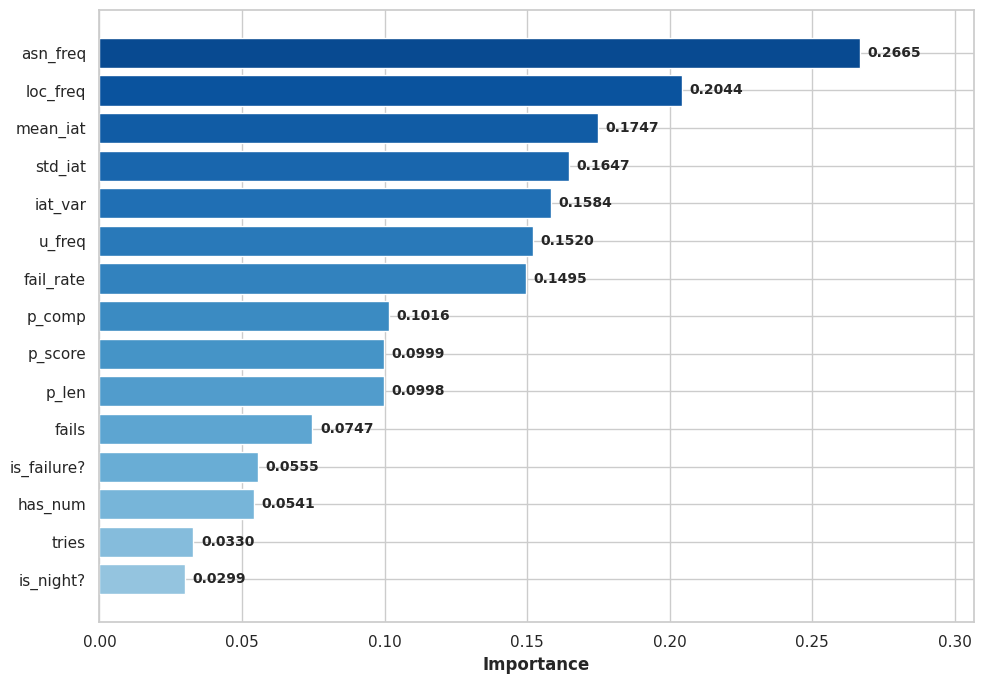

In [ ]:
mi_scores = mutual_info_classif(X_train_final, y_train, random_state=42)
feature_columns = X_train_final.columns

mi_df = pd.DataFrame({
    'Feature': feature_columns,
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

print(mi_df.head(15))

plt.figure(figsize=(10, 7))

top_15_mi = mi_df.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_15_mi)))

bars = plt.barh(range(len(top_15_mi)), top_15_mi['MI_Score'].values, color=colors[::-1])

plt.yticks(range(len(top_15_mi)), top_15_mi['Feature'].values)
plt.xlabel('Importance', fontsize=12, fontweight='bold')

plt.gca().invert_yaxis()

plt.xlim(0, top_15_mi['MI_Score'].max() * 1.15)

for i, (bar, val) in enumerate(zip(bars, top_15_mi['MI_Score'].values)):
    plt.text(bar.get_width() + (top_15_mi['MI_Score'].max() * 0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}',
             va='center',
             fontsize=10,
             fontweight='bold')

plt.tight_layout()
plt.show()

Correlation Matrix

In [ ]:
report_dict = classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=['Normal', 'Attack'],
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report_dict).transpose()

for col in ['precision', 'recall', 'f1-score']:
    df_report[col] = df_report[col].apply(lambda x: f"{x*100:.2f}%")

display(df_report)

,precision,recall,f1-score,support
Normal,84.35%,74.22%,78.96%,70329.000000
Attack,77.55%,86.60%,81.82%,72294.000000
accuracy,80.50%,80.50%,80.50%,0.804982
macro avg,80.95%,80.41%,80.39%,142623.000000
weighted avg,80.90%,80.50%,80.41%,142623.000000


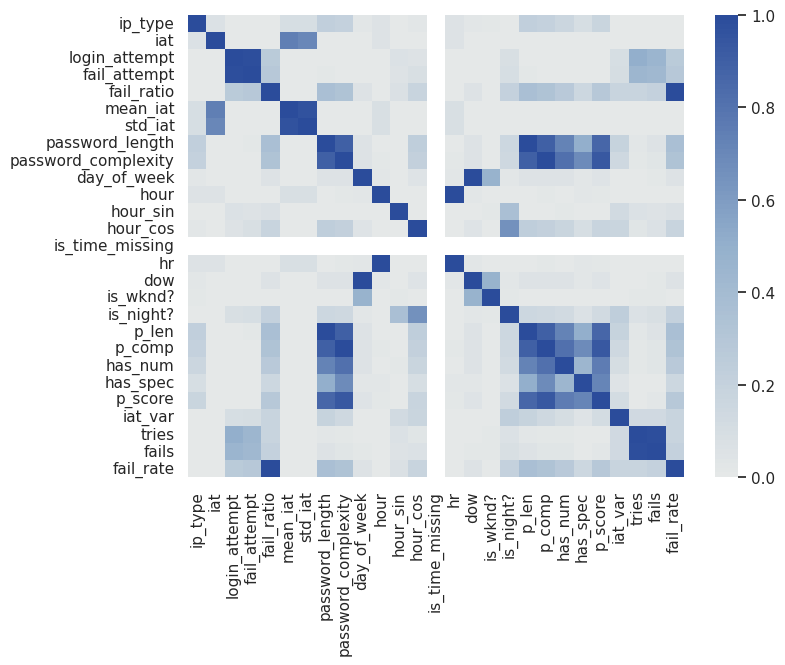

In [ ]:
plt.figure(figsize=(8,6))
colors = ["#E5E8E8", "#94B0CC", "#2B4C9B"]
n_bins = 100
sns.set_style("white")
cmap_name = "gray_to_blue"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
corr_matrix = X_final.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap=custom_cmap, annot=False, fmt=".2f", vmin=0, vmax=1)
plt.show()

Confusion Matrix


4457/4457 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step


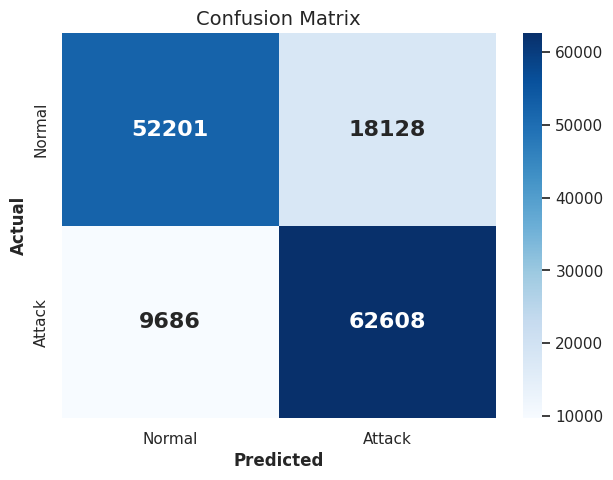

In [ ]:
class_names = ['Normal', 'Attack']

y_test_pred_probs = cnn_model.predict(X_test_scaled)
y_test_pred = (y_test_pred_probs > 0.5).astype(int) # Convert probabilities to binary predictions

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues",
            annot_kws={"size": 16, "weight": "bold"})

plt.xlabel("Predicted", fontsize=12, fontweight='bold')
plt.ylabel("Actual", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix", fontsize=14)
plt.show()

Classification report heatmap

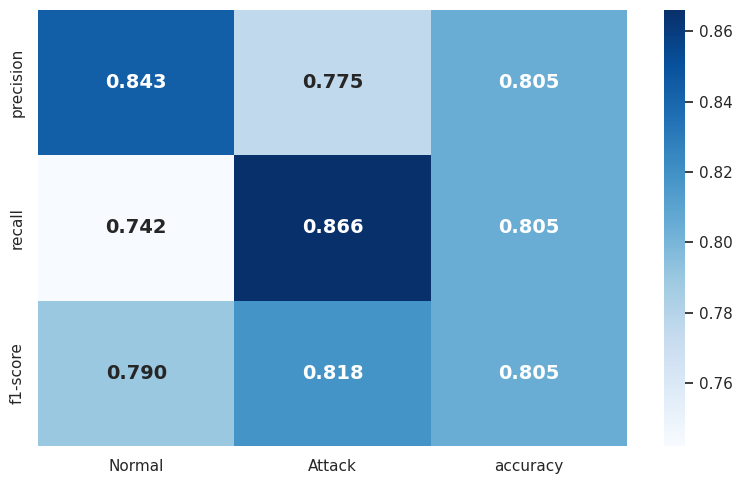

In [ ]:
report = classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=['Normal', 'Attack'],
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).iloc[:-1, :3]

plt.figure(figsize=(8,5))
sns.heatmap(report_df, annot=True, fmt=".3f",
            cmap="Blues", annot_kws={"size": 14, "weight": "bold"})
plt.tight_layout()
plt.show()

Operational Performance & Security Metrics

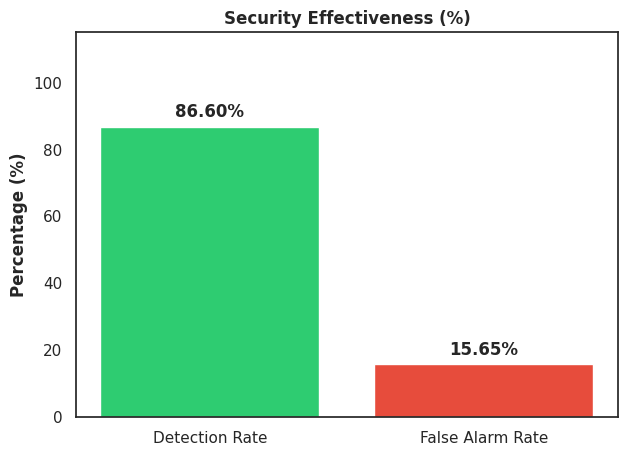

In [ ]:
attack_recall = report['Attack']['recall']
normal_precision = report['Normal']['precision']

detection_rate = attack_recall * 100
far_rate = (1 - normal_precision) * 100

fig, ax1 = plt.subplots(figsize=(7, 5))

metrics = ['Detection Rate', 'False Alarm Rate']
values = [detection_rate, far_rate]

ax1.bar(metrics, values, color=['#2ECC71', '#E74C3C'])

ax1.set_ylim(0, 115)
ax1.set_title('Security Effectiveness (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontweight='bold')

for i, v in enumerate(values):
    ax1.text(i, v + 3, f"{v:.2f}%", ha='center', fontweight='bold')

plt.show()

SHAP Explanation

In [ ]:
background_for_explainer = X_train_cnn[:100].reshape(100, -1)
X_sample_for_explainer = X_test_cnn[:50]
X_sample_for_plot = X_test[:50]

In [ ]:
print("SHAP Explanation (CNN):")
explainer = shap.DeepExplainer(cnn_model, X_train_cnn[:100]) # Pass 3D background data
shap_values = explainer.shap_values(X_sample_for_explainer)

if isinstance(shap_values, list):
    shap_values_reshaped = shap_values[0].squeeze()
else:
    shap_values_reshaped = shap_values.squeeze()
    print(f"SHAP values shape: {shap_values_reshaped.shape}")

SHAP Explanation (CNN):
SHAP values shape: (50, 21)



 Beeswarm Plot - Class 0 (Normal)


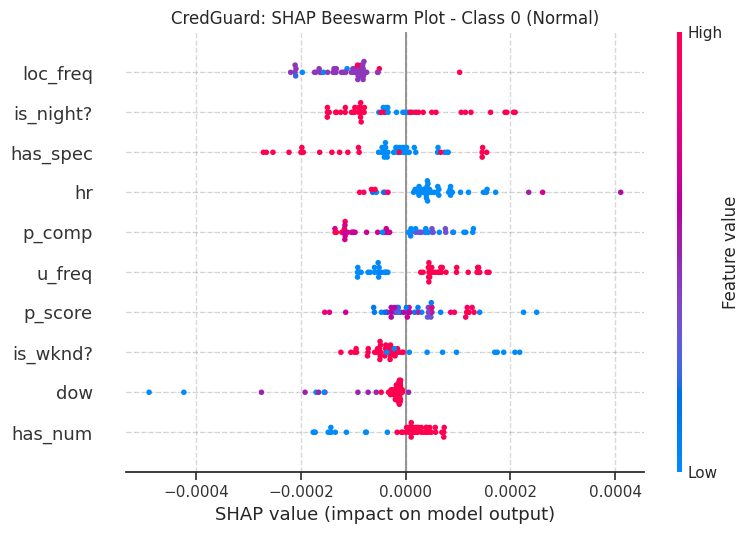


 Beeswarm Plot - Class 1 (Attack)


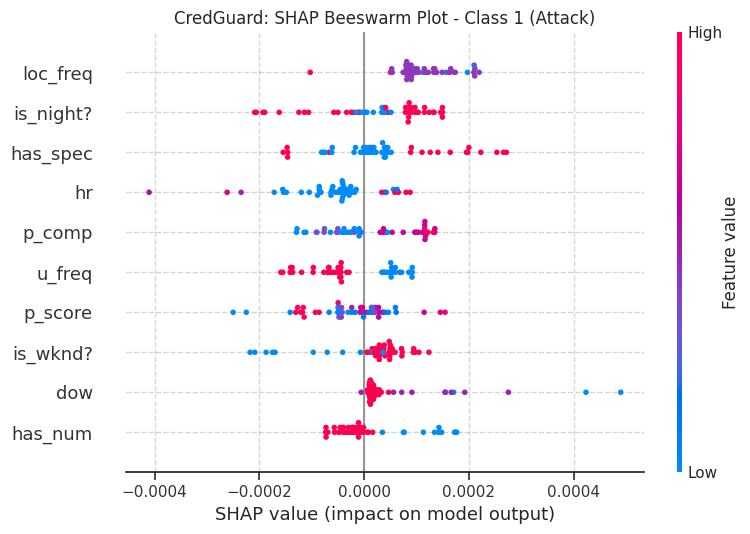

In [ ]:
# Beeswarm plots

shap_values_class_1 = shap_values_reshaped
shap_values_class_0 = -shap_values_reshaped

X_sample_for_explainer_squeezed = X_sample_for_explainer.squeeze()

print("\n Beeswarm Plot - Class 0 (Normal)")
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class_0,
    X_sample_for_explainer_squeezed,
    feature_names=X_test_scaled.columns.tolist(),
    max_display=10,
    plot_type="dot",
    show=False
)
plt.title("CredGuard: SHAP Beeswarm Plot - Class 0 (Normal)")
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.show()


print("\n Beeswarm Plot - Class 1 (Attack)")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_class_1,
    X_sample_for_explainer_squeezed,
    feature_names=X_test_scaled.columns.tolist(),
    max_display=10,
    plot_type="dot",
    show=False
)
plt.title("CredGuard: SHAP Beeswarm Plot - Class 1 (Attack)")
plt.grid(True, linestyle='--', alpha=0.3, color='gray')
plt.tight_layout()
plt.show()


Global Feature Importance


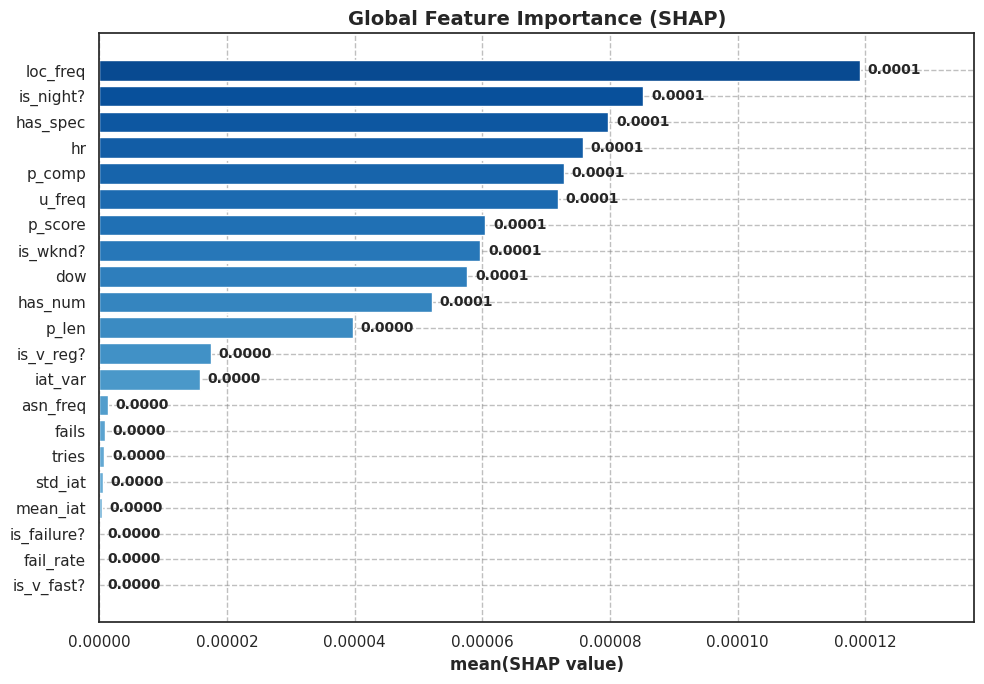

In [ ]:
# Global Feature Importance
print("\nGlobal Feature Importance")

if isinstance(shap_values, list):
    shap_array_for_global = np.stack([s.squeeze() for s in shap_values], axis=-1)
else:
    shap_array_for_global = shap_values.squeeze()

mean_abs_shap = np.mean(np.abs(shap_array_for_global), axis=0)
importance = mean_abs_shap

feature_names = np.array(training_features)
indices = np.argsort(importance)[::-1]
labels_for_plot = feature_names[indices].tolist()
importance_sorted = importance[indices]

plt.figure(figsize=(10, 7))

top_n = len(labels_for_plot)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
bars = plt.barh(range(top_n), importance_sorted, color=colors[::-1])

plt.yticks(range(top_n), labels_for_plot)
plt.xlabel('mean(SHAP value)', fontsize=12, fontweight='bold')
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')

plt.gca().invert_yaxis()

plt.xlim(0, importance_sorted.max() * 1.15)

for i, (bar, val) in enumerate(zip(bars, importance_sorted)):
    plt.text(bar.get_width() + (importance_sorted.max() * 0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.4f}',
             va='center',
             fontsize=10,
             fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

LIME Explanation

In [ ]:
normal_indices = y_test[y_test == 0].index[:3].tolist()  # 3 Normal samples
attack_indices = y_test[y_test == 1].index[:3].tolist()  # 3 Attack samples

# Combine all samples
samples_to_explain = normal_indices + attack_indices

LIME EXPLANATION (DNN):

Random sample selected: 57314
True label: Normal
Model predicted: Attack (confidence: 0.609)
LIME explaining class: Attack
 MISCLASSIFICATION!

Feature Contributions:
has_num                             → +0.0342
p_len                               → +0.0327
is_wknd?                            → +0.0310
mean_iat                            → +0.0295
p_comp                              → +0.0244
loc_freq                            → +0.0224
is_failure?                         → +0.0221
asn_freq                            → +0.0207
u_freq                              → +0.0149
hr                                  → +0.0134


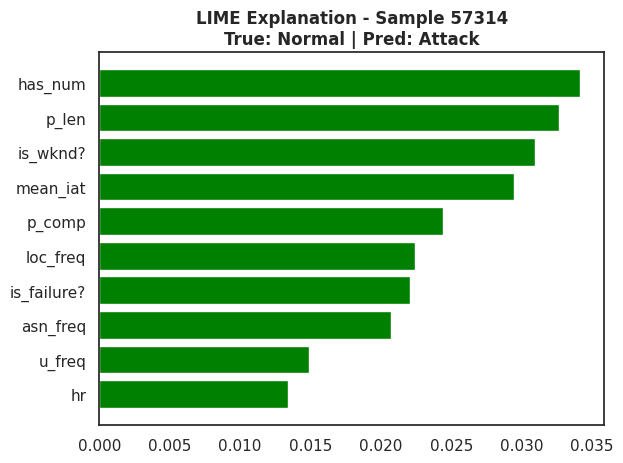

In [ ]:
print("LIME EXPLANATION (DNN):")
# Class names for binary
class_names = ['Normal', 'Attack']

def predict_proba_lime(X_unscaled):
    X_unscaled = np.array(X_unscaled)

    if X_unscaled.ndim == 1:
        X_unscaled = X_unscaled.reshape(1, -1)

    X_df = pd.DataFrame(X_unscaled, columns=training_features)

    X_scaled = scaler.transform(X_df)

    preds = cnn_model.predict(X_scaled, verbose=0)

    if preds.shape[1] == 1:
        preds = preds.flatten()
        return np.column_stack([1 - preds, preds])

    return preds

X_lime_background = X_train_final.values.astype(np.float64)
lime_feature_names = training_features

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_lime_background,
    feature_names=lime_feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=False,
    random_state=42
)

sample_idx = random.randint(0, len(X_test_final) - 1)

sample_values = X_test_final.iloc[sample_idx].values

exp = explainer_lime.explain_instance(
    data_row=sample_values,
    predict_fn=predict_proba_lime,
    num_features=10
)

single_sample_df = pd.DataFrame(
    sample_values.reshape(1, -1),
    columns=training_features
)

single_sample_scaled = scaler.transform(single_sample_df)
pred_probs = cnn_model.predict(single_sample_scaled, verbose=0)

# Handle sigmoid output
if pred_probs.shape[1] == 1:
    pred_prob = pred_probs[0][0]
    pred_class_idx = 1 if pred_prob > 0.5 else 0
    confidence = pred_prob if pred_class_idx == 1 else 1 - pred_prob
else:
    pred_class_idx = np.argmax(pred_probs, axis=1)[0]
    confidence = pred_probs[0][pred_class_idx]

pred_class_name = class_names[pred_class_idx]

true_label = y_test_final.iloc[sample_idx]
true_label_name = class_names[true_label]

label_from_lime = exp.available_labels()[0]

print(f"\nRandom sample selected: {sample_idx}")
print(f"True label: {true_label_name}")
print(f"Model predicted: {pred_class_name} (confidence: {confidence:.3f})")
print(f"LIME explaining class: {class_names[label_from_lime]}")

if true_label != pred_class_idx:
    print(" MISCLASSIFICATION!")

print("\nFeature Contributions:")
for feature, weight in exp.as_list(label=label_from_lime):
   print(f"{feature:35} → {weight:+.4f}")

fig = exp.as_pyplot_figure(label=label_from_lime)

plt.title(
    f"LIME Explanation - Sample {sample_idx}\nTrue: {true_label_name} | Pred: {pred_class_name}",
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

Save Model

In [ ]:
cnn_model.save('cnn_ids_model.h5')

model_files = {
    'model': cnn_model,
    'scaler': scaler,
    'features': training_features
}
for name, obj in model_files.items():
    filename = f'cnn_ids_{name}.pkl'
    joblib.dump(obj, filename)
    print(f"Saved: {filename}")

Saved: cnn_ids_model.pkl
Saved: cnn_ids_scaler.pkl
Saved: cnn_ids_features.pkl


In [ ]:
print("FINAL SUMMARY - CNN MODEL")
top_features = mi_df.head(3)
print(f"""
╔══════════════════════════════════════════════════════════╗
║                 CNN MODEL PERFORMANCE SUMMARY            ║
╠══════════════════════════════════════════════════════════╣
║
║     ACCURACY:
║  • Training:   {train_acc:.2%}
║  • Validation: {val_acc:.2%}
║  • Test:       {test_acc:.2%}
║
║  SECURITY METRICS:
║  • Attack Detection Rate (Recall): {attack_recall:.2%}
║  • False Alarm Rate: {1 - normal_precision:.2%}
║  • System Reliability (Attack Precision): {report['Attack']['precision']:.2%}
║
║  MODEL EFFICIENCY:
║  • Overall Accuracy: {test_acc:.2%}
║  • F1-Score (Weighted): {test_f1:.2%}
║
║  PER-CLASS F1-SCORES:
║  • Normal: {report['Normal']['f1-score']:.2%}
║  • Attack: {report['Attack']['f1-score']:.2%}
║
║  TOP FEATURES INFLUENCING DETECTION:
║  1. {top_features.iloc[0]['Feature']}
║  2. {top_features.iloc[1]['Feature']}
║  3. {top_features.iloc[2]['Feature']}
║
║  DATA DISTRIBUTION:
║  • Total samples: {len(df)}
║  • Features used: {len(training_features)}
║  • Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}
║
╚══════════════════════════════════════════════════════════╝
""")

FINAL SUMMARY - CNN MODEL

╔══════════════════════════════════════════════════════════╗
║                 CNN MODEL PERFORMANCE SUMMARY            ║
╠══════════════════════════════════════════════════════════╣
║
║     ACCURACY:
║  • Training:   80.82%
║  • Validation: 82.63%
║  • Test:       80.50%
║
║  SECURITY METRICS:
║  • Attack Detection Rate (Recall): 86.60%
║  • False Alarm Rate: 15.65%
║  • System Reliability (Attack Precision): 77.55%
║
║  MODEL EFFICIENCY:
║  • Overall Accuracy: 80.50%
║  • F1-Score (Weighted): 80.41%
║
║  PER-CLASS F1-SCORES:
║  • Normal: 78.96%
║  • Attack: 81.82%
║
║  TOP FEATURES INFLUENCING DETECTION:
║  1. asn_freq
║  2. loc_freq
║  3. mean_iat
║
║  DATA DISTRIBUTION:
║  • Total samples: 1019867
║  • Features used: 21
║  • Train/Val/Test: 704222/173022/142623
║
╚══════════════════════════════════════════════════════════╝

